## generate a testing data: 16x16 image

In [196]:
import numpy as np
from PIL import Image

# Change this to generate more samples
no_of_sample_digits = 3

# Select random digits
digits = np.random.choice(range(10), size=no_of_sample_digits, replace=False)

# Get corresponding images path from MNIST dataset directory(sample MNIST data/))
img_paths = [f"sample MNIST data/{d}.png" for d in digits]

for i, img_path in enumerate(img_paths):
    print(f"True Label: {digits[i]}")
    print(f"Image Path: {img_path}")

    img28 = Image.open(img_path).convert("L")  # grayscale
    img28 = np.array(img28)

    # Downsample to 16x16
    img16 = np.array(Image.fromarray(img28).resize((16,16), Image.BILINEAR))

    # Flatten to 1D array
    flat = img16.flatten()

    # Convert to VHDL std_logic_vector hex format
    vhdl_str = ""
    for i, pix in enumerate(flat):
        vhdl_str += f"{i} => x\"{pix:02X}\""
        if i != len(flat)-1:
            vhdl_str += ", "

    print(vhdl_str)
    print()


True Label: 8
Image Path: sample MNIST data/8.png
0 => x"00", 1 => x"00", 2 => x"00", 3 => x"00", 4 => x"00", 5 => x"00", 6 => x"00", 7 => x"00", 8 => x"00", 9 => x"00", 10 => x"00", 11 => x"00", 12 => x"00", 13 => x"00", 14 => x"00", 15 => x"00", 16 => x"00", 17 => x"00", 18 => x"00", 19 => x"00", 20 => x"00", 21 => x"00", 22 => x"00", 23 => x"00", 24 => x"00", 25 => x"00", 26 => x"00", 27 => x"00", 28 => x"00", 29 => x"00", 30 => x"00", 31 => x"00", 32 => x"00", 33 => x"00", 34 => x"00", 35 => x"00", 36 => x"00", 37 => x"00", 38 => x"19", 39 => x"68", 40 => x"AB", 41 => x"74", 42 => x"03", 43 => x"00", 44 => x"00", 45 => x"00", 46 => x"00", 47 => x"00", 48 => x"00", 49 => x"00", 50 => x"00", 51 => x"00", 52 => x"03", 53 => x"30", 54 => x"AB", 55 => x"F0", 56 => x"F3", 57 => x"B2", 58 => x"68", 59 => x"78", 60 => x"3B", 61 => x"04", 62 => x"00", 63 => x"00", 64 => x"00", 65 => x"00", 66 => x"00", 67 => x"00", 68 => x"10", 69 => x"B9", 70 => x"F6", 71 => x"E3", 72 => x"9A", 73 => x"80"

## SNN network implementation

In [176]:
%pip install snntorch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [235]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os


In [206]:
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 16x16 → 256
])


batch_size = 64
train_ds = datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_ds  = datasets.MNIST(root="data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:41<00:00, 239kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 87.4kB/s]
100%|██████████| 1.65M/1.65M [00:12<00:00, 134kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 492kB/s]


### SNN Architecture (LIF Model)

Here we consider only 1 hidden layer.
I don't  pass the threshold in any snn.Leaky(). So it uses the default **threshold = 1.0**

In [232]:
class SNN_FPGAModel(nn.Module):
    def __init__(self, hidden1=32, hidden2=None, beta=0.9):
        super().__init__()
        self.hidden2 = hidden2

        # First fully connected layer and LIF neuron
        self.fc1 = nn.Linear(256, hidden1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        
        # Optional: if you need 2 hidden layers
        if hidden2:
            self.fc2 = nn.Linear(hidden1, hidden2)
            self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
            self.fc3 = nn.Linear(hidden2, 10)
        else: 
            # Default: Single hidden layer
            self.fc3 = nn.Linear(hidden1, 10)

        self.lif_out = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x, num_steps=20):
        # RESET STATES FOR EACH FORWARD PASS
        mem1 = self.lif1.init_leaky()
        if self.hidden2:
            mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []

        for t in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            if self.hidden2:
                cur2 = self.fc2(spk1)
                spk2, mem2 = self.lif2(cur2, mem2)

                cur3 = self.fc3(spk2)
            else:
                cur3 = self.fc3(spk1)

            spk_out, mem_out = self.lif_out(cur3, mem_out)
            spk_rec.append(spk_out)

        return torch.stack(spk_rec)
    

    # Debug forward pass with full internal state capture
    def forward_debug(self, x, num_steps=20):
        # Reset states
        mem1 = self.lif1.init_leaky()
        if self.hidden2:
            mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        # Storage dictionaries
        debug = {
            "cur1": [], "mem1": [], "spk1": [],
        }

        if self.hidden2:
            debug.update({
                "cur2": [], "mem2": [], "spk2": [],
            })

        debug.update({
            "cur_out": [], "mem_out": [], "spk_out": [],
        })

        # Time loop
        for t in range(num_steps):
            # ------ Layer 1 ------
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            debug["cur1"].append(cur1.detach().cpu().numpy())
            debug["mem1"].append(mem1.detach().cpu().numpy())
            debug["spk1"].append(spk1.detach().cpu().numpy())

            # ------ Layer 2 (optional) ------
            if self.hidden2:
                cur2 = self.fc2(spk1)
                spk2, mem2 = self.lif2(cur2, mem2)

                debug["cur2"].append(cur2.detach().cpu().numpy())
                debug["mem2"].append(mem2.detach().cpu().numpy())
                debug["spk2"].append(spk2.detach().cpu().numpy())

                cur3 = self.fc3(spk2)
            else:
                cur3 = self.fc3(spk1)

            # ------ Output Layer ------
            spk_out, mem_out = self.lif_out(cur3, mem_out)

            debug["cur_out"].append(cur3.detach().cpu().numpy())
            debug["mem_out"].append(mem_out.detach().cpu().numpy())
            debug["spk_out"].append(spk_out.detach().cpu().numpy())

        return debug




### Training and Evaluation

In [233]:
device = "cuda" if torch.cuda.is_available() else "cpu"

hidden_neurons = 64  # No of neurons in hidden layer
beta = 0.9
threshold = 1.0 # We don't pass threshold, so default 1.0 is used

model = SNN_FPGAModel(hidden1=hidden_neurons, hidden2=None, beta=beta).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = SF.ce_rate_loss()
num_steps = 20


Epoch 1: Loss=100022.603, Acc=0.8458
Epoch 2: Loss=93021.383, Acc=0.9286
Epoch 3: Loss=91876.843, Acc=0.9402
Epoch 4: Loss=91228.528, Acc=0.9482
Epoch 5: Loss=90827.014, Acc=0.9525
Epoch 6: Loss=90544.399, Acc=0.9573
Epoch 7: Loss=90296.729, Acc=0.9606
Epoch 8: Loss=90130.577, Acc=0.9624
Epoch 9: Loss=89979.024, Acc=0.9649
Epoch 10: Loss=89873.010, Acc=0.9665


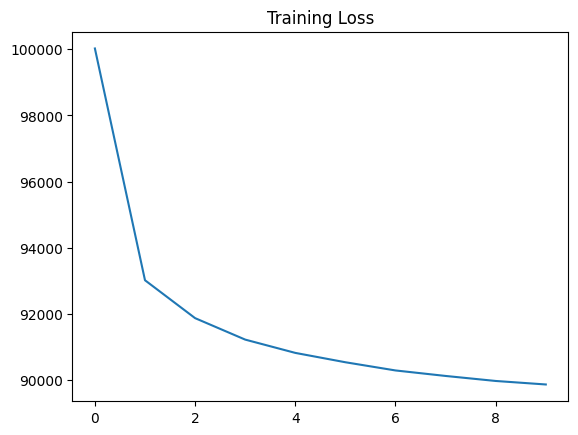

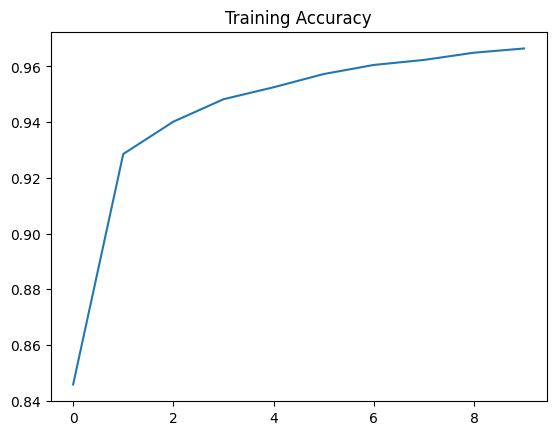

In [209]:
epochs = 10
loss_hist = []
acc_hist = []

for ep in range(epochs):
    total_correct = 0
    total_loss = 0

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward pass (collect spikes over time)
        spk_rec = model(x, num_steps)   # shape: [T, B, C]

        # Compute prediction from spike counts BEFORE calling backward.
        # This avoids using tensors freed by autograd after backward().
        spk_sum = spk_rec.sum(0)       # [B, C]
        _, pred = spk_sum.max(1)

        # Compute loss and backpropagate
        loss = loss_fn(spk_rec, y)
        loss.backward()
        optimizer.step()

        # Accumulate statistics (use .item() so we don't keep graph)
        total_loss += loss.item() * x.size(0)
        total_correct += (pred == y).sum().item()

    acc = total_correct / len(train_ds)
    loss_hist.append(total_loss)
    acc_hist.append(acc)

    print(f"Epoch {ep+1}: Loss={total_loss:.3f}, Acc={acc:.4f}")

# Save the trained model
torch.save(model.state_dict(), "snn_fpga_model.pth")


# Plot training curves
plt.plot(loss_hist)
plt.title("Training Loss")
plt.show()

plt.plot(acc_hist)
plt.title("Training Accuracy")
plt.show()

In [210]:
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        spk_rec = model(x, num_steps)
        _, pred = spk_rec.sum(0).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())


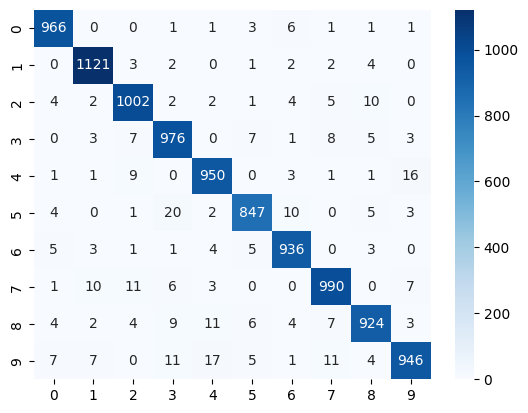

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.97      0.95      0.96       892
           6       0.97      0.98      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.95      0.96       974
           9       0.97      0.94      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [211]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()


print(classification_report(all_labels, all_preds))


### Weight Export for VHDL

Generates a VHDL package (weights_pkg.vhd) from numpy weight/bias arrays.

Supports configurable fixed-point quantization Qm.n by specifying fractional bits (q_frac_bits).
Default uses Q8.8 (q_frac_bits = 8) -> scale = 256.

Expected array shapes:
 - W_input_hidden:  (N_HIDDEN, N_INPUTS)
 - B_input_hidden:  (N_HIDDEN,)
 - W_hidden_output: (N_OUTPUT, N_HIDDEN)
 - B_hidden_output: (N_OUTPUT,)

If you have only one hidden layer, pass W_hidden_output, B_hidden_output as normal.
If you have two hidden layers you can extended this script similarly.

In [236]:
# take all the model weights and biases. Then save all the data inside a numpy arreay having the following keys with the array shape:
#  - W_input_hidden:  (N_HIDDEN, N_INPUTS)
#  - B_input_hidden:  (N_HIDDEN,)
#  - W_hidden_output: (N_OUTPUT, N_HIDDEN)
#  - B_hidden_output: (N_OUTPUT,)
# Save the numpy array to a file named "snn_fpga_weights.npz"

model = SNN_FPGAModel(hidden1=hidden_neurons, hidden2=None, beta=beta)
weights_dict = {
    "hidden_neurons": hidden_neurons,
    "beta": beta,
    "threshold": threshold,
    "W_input_hidden": model.fc1.weight.detach().cpu().numpy(),
    "B_input_hidden": model.fc1.bias.detach().cpu().numpy(),
    "W_hidden_output": model.fc3.weight.detach().cpu().numpy(),
    "B_hidden_output": model.fc3.bias.detach().cpu().numpy(),
}

np.savez("snn_fpga_weights.npz", **weights_dict)

In [241]:
# Helper: convert numpy int array to vhdl row string
def _vhdl_row_list(arr_row):
    # return string like "0 => 12, 1 => -3, 2 => 0"
    elems = []
    for j, v in enumerate(arr_row):
        elems.append(f"{j} => {int(v)}")
    return ", ".join(elems)


def write_weights_pkg_vhdl(
    filename: str,
    W_input_hidden: np.ndarray,
    B_input_hidden: np.ndarray,
    W_hidden_output: np.ndarray,
    B_hidden_output: np.ndarray,
    q_frac_bits: int = 8,
    lif_beta: float = 0.9,        # leaky beta, in float (0..1)
    threshold: float = 1.0,       # threshold in same scale as activations (float)
    vhdl_pkg_name: str = "weights_pkg",
    comment: str = ""
):
    """
    Write a VHDL package file containing quantized weights & biases and helper constants.

    - filename: output file path (e.g. "weights_pkg.vhd")
    - q_frac_bits: number of fractional bits (n in Qm.n). Q8.8 => q_frac_bits = 8
    - lif_beta, threshold will be quantized with same Q format
    """
    # Validate shapes
    W_input_hidden = np.asarray(W_input_hidden)
    B_input_hidden = np.asarray(B_input_hidden)
    W_hidden_output = np.asarray(W_hidden_output)
    B_hidden_output = np.asarray(B_hidden_output)

    assert W_input_hidden.ndim == 2, "W_input_hidden must be 2D (N_HIDDEN, N_INPUTS)"
    assert W_hidden_output.ndim == 2, "W_hidden_output must be 2D (N_OUTPUT, N_HIDDEN)"
    assert B_input_hidden.ndim == 1
    assert B_hidden_output.ndim == 1

    N_HIDDEN, N_INPUTS = W_input_hidden.shape
    N_OUTPUT, N_HIDDEN2 = W_hidden_output.shape
    assert N_HIDDEN == N_HIDDEN2, "Hidden size mismatch between W_input_hidden and W_hidden_output"
    assert B_input_hidden.size == N_HIDDEN
    assert B_hidden_output.size == N_OUTPUT

    # Quantization parameters
    Q_BITS = q_frac_bits
    Q_SCALE = 1 << Q_BITS
    Q_NAME = f"Q{(16-Q_BITS)}.{Q_BITS}"  # rough label (not exact m bits)
    INT_MIN, INT_MAX = -32768, 32767  # matches int16 subtype in types_pkg

    # Quantize arrays (round -> int)
    def q(arr):
        a = np.rint(np.asarray(arr, dtype=np.float64) * Q_SCALE).astype(np.int64)
        # clip to int16 range
        a = np.clip(a, INT_MIN, INT_MAX)
        return a.astype(np.int32)

    W1_q = q(W_input_hidden)
    B1_q = q(B_input_hidden)
    W3_q = q(W_hidden_output)
    B3_q = q(B_hidden_output)

    lif_beta_q = int(round(lif_beta * Q_SCALE))
    threshold_q = int(round(threshold * Q_SCALE))

    # Write VHDL
    with open(filename, "w") as f:
        f.write(f"-- Auto-generated VHDL weights package\n")
        f.write(f"-- Source: snn_test.ipynb\n")
        f.write(f"-- Format: fixed-point {Q_NAME} (frac bits={Q_BITS}, scale={Q_SCALE})\n")
        if comment:
            f.write(f"-- {comment}\n")
        f.write("\n")
        f.write("library IEEE;\n")
        f.write("use IEEE.STD_LOGIC_1164.ALL;\n")
        f.write("use IEEE.NUMERIC_STD.ALL;\n")
        f.write("use work.types_pkg.all;\n\n")
        f.write(f"package {vhdl_pkg_name} is\n\n")

        # sizes and Q constants
        f.write(f"  -- Network sizes\n")
        f.write(f"  constant N_INPUTS  : integer := {N_INPUTS};\n")
        f.write(f"  constant N_HIDDEN  : integer := {N_HIDDEN};\n")
        f.write(f"  constant N_OUTPUT  : integer := {N_OUTPUT};\n\n")

        f.write(f"  -- Fixed-point quantization (Q format)\n")
        f.write(f"  -- fractional bits (n): number of bits for fraction\n")
        f.write(f"  constant Q_FRAC_BITS : integer := {Q_BITS};\n")
        f.write(f"  constant Q_SCALE     : integer := {Q_SCALE};  -- scaling factor (2^Q_FRAC_BITS)\n\n")

        f.write(f"  -- LIF / neuron parameters (quantized in same Q format)\n")
        f.write(f"  constant LIF_BETA_Q  : integer := {lif_beta_q};  -- beta * Q_SCALE\n")
        f.write(f"  constant THRESHOLD_Q : integer := {threshold_q};  -- threshold * Q_SCALE\n\n")

        # Declare constants using integer_matrix/integer_vector types from types_pkg
        f.write("  -- Weight matrices (quantized integers, clipped to int16 range)\n")
        f.write(f"  constant W_INPUT_HIDDEN : integer_matrix(0 to {N_HIDDEN-1}, 0 to {N_INPUTS-1}) := (\n")
        for n in range(N_HIDDEN):
            row = _vhdl_row_list(W1_q[n])
            sep = "," if n < N_HIDDEN-1 else ""
            f.write(f"    {n} => ({row}){sep}\n")
        f.write("  );\n\n")

        f.write(f"  constant B_INPUT_HIDDEN : integer_vector(0 to {N_HIDDEN-1}) := (")
        f.write(", ".join(str(int(x)) for x in B1_q))
        f.write(");\n\n")

        f.write(f"  constant W_HIDDEN_OUTPUT : integer_matrix(0 to {N_OUTPUT-1}, 0 to {N_HIDDEN-1}) := (\n")
        for n in range(N_OUTPUT):
            row = _vhdl_row_list(W3_q[n])
            sep = "," if n < N_OUTPUT-1 else ""
            f.write(f"    {n} => ({row}){sep}\n")
        f.write("  );\n\n")

        f.write(f"  constant B_HIDDEN_OUTPUT : integer_vector(0 to {N_OUTPUT-1}) := (")
        f.write(", ".join(str(int(x)) for x in B3_q))
        f.write(");\n\n")

        f.write(f"  -- Helpful human-readable info (floating point equivalents)\n")
        f.write(f"  -- NOTE: stored integers represent value * Q_SCALE\n")
        f.write(f"  -- Example: real_weight = stored_int / Q_SCALE\n\n")

        f.write("end package " + vhdl_pkg_name + ";\n")

    print(f"[OK] Wrote VHDL package to {os.path.abspath(filename)}")
    print(f"  format: Q frac bits = {Q_BITS} (scale={Q_SCALE}), lif_beta_q={lif_beta_q}, threshold_q={threshold_q}")
    print(f"  shapes: W1 {W1_q.shape}, B1 {B1_q.shape}, W3 {W3_q.shape}, B3 {B3_q.shape}")

In [242]:

data = np.load("snn_fpga_weights.npz")   # change path if necessary

W_input_hidden  = data["W_input_hidden"]   # (N_HIDDEN, N_INPUTS)
B_input_hidden  = data["B_input_hidden"]
W_hidden_output = data["W_hidden_output"]  # (N_OUTPUT, N_HIDDEN)
B_hidden_output = data["B_hidden_output"]
hidden_neurons_no = data["hidden_neurons"].item()
neuron_beta       = data["beta"].item()
neuron_threshold  = data["threshold"].item()

# Choose quantization: q_frac_bits = 8 -> Q8.8
write_weights_pkg_vhdl(
    filename="weights_pkg.vhd",
    W_input_hidden=W_input_hidden,
    B_input_hidden=B_input_hidden,
    W_hidden_output=W_hidden_output,
    B_hidden_output=B_hidden_output,
    q_frac_bits=8,
    lif_beta=neuron_beta,
    threshold=neuron_threshold,
    comment="Generated from trained model (Q8.8)."
)


[OK] Wrote VHDL package to e:\Programmes\SNN-FPGA\Python scripts\weights_pkg.vhd
  format: Q frac bits = 8 (scale=256), lif_beta_q=230, threshold_q=256
  shapes: W1 (64, 256), B1 (64,), W3 (10, 64), B3 (10,)


## Model simulation

### Load PNG & preprocess (MNIST style)

In [212]:
from PIL import Image

def load_mnist_png(path):
    img = Image.open(path).convert("L")   # grayscale
    img = img.resize((16, 16))            # your FPGA uses 256 inputs
    arr = np.array(img).astype(np.float32) / 255.0
    arr = torch.tensor(arr).flatten()     # shape: (256,)
    return arr

sample = load_mnist_png("E:\\Programmes\\SNN-FPGA\\Python scripts\\sample MNIST data\\1.png")
print(sample.shape)   # torch.Size([256])


torch.Size([256])


### Forward-pass with full internal state capture

In [ ]:
sample = sample.to(device)

# get the model from saved "snn_fpga_model.pth"
model = SNN_FPGAModel(hidden1=hidden_neurons, hidden2=None, beta=beta)
model.load_state_dict(torch.load("snn_fpga_model.pth"))
model.to(device)
model.eval()

with torch.no_grad():
    debug_data = model.forward_debug(sample, num_steps=20)

print(debug_data.keys())  # should show all captured variables


dict_keys(['cur1', 'mem1', 'spk1', 'cur_out', 'mem_out', 'spk_out'])


In [221]:
np.savetxt("layer1_mem.csv", np.array(debug_data["mem1"]), delimiter=",")

